# Statistical and mechanistic analysis

This notebook contains only the analyses needed for the manuscript:

1. mixed-effects analysis of phase-level experimental descriptors;
2. a fair comparison between two dynamic models fitted to the same dorsal-temperature samples;
3. exclusion of numerically unstable fits using criteria defined before inferential analysis;
4. mixed-effects analysis of the fitted rate constant using stable fits only.

Cooling rate and ACI are intentionally not computed.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.integrate import solve_ivp
from scipy.stats import wilcoxon
import statsmodels.formula.api as smf


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Project root not found. Run the notebook inside the repository.")


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


ROOT = find_project_root()
FEATURES_DIR = ROOT / "data" / "processed" / "features"
OUTPUT_DIR = ensure_dir(ROOT / "reports" / "06_statistics" / "clean_model_analysis")

DATA_PATH = FEATURES_DIR / "analysis_dataset_with_tsk.csv"
PHASE_FEATURES_PATH = FEATURES_DIR / "phase_features_long.csv"

SUBJECT_COL = "subject_id"
CONDITION_COL = "condition"
PHASE_COL = "phase"
TIME_COL = "elapsed_seconds"
T_DORSAL_COL = "t_dorsal"
T_MICRO_COL = "t_microclimateback"

PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]
PHASE_LABELS = {p: f"Phase {i + 1}" for i, p in enumerate(PHASE_ORDER)}
CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]

# Identical analysis window for both dynamic models.
WINDOW_SECONDS = 180.0
TRAIN_FRACTION = 0.70
MIN_POINTS = 30
MIN_TIME_SPAN_S = 60.0
MIN_TEMPERATURE_RANGE_C = 0.05

# Stability criteria. These do not depend on R2 or statistical significance.
BOUND_TOL = 1e-4
MAX_RELATIVE_SE_K = 1.0
K_BOUNDS = (1e-5, 0.2)       # s^-1; tau between 5 s and 27.8 h
TEQ_BOUNDS = (15.0, 45.0)    # degC
A_BOUNDS = (-0.1, 0.1)       # degC/s

print("ROOT:", ROOT)
print("Output:", OUTPUT_DIR)


ROOT: /home/eleonorab/repository/convective_cooling
Output: /home/eleonorab/repository/convective_cooling/reports/06_statistics/clean_model_analysis


In [2]:
def require_columns(df: pd.DataFrame, columns: list[str], name: str) -> None:
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")


raw = pd.read_csv(DATA_PATH)
require_columns(
    raw,
    [SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL, T_DORSAL_COL, T_MICRO_COL],
    "Dynamic dataset",
)

raw = raw[raw[PHASE_COL].isin(PHASE_ORDER) & raw[CONDITION_COL].isin(CONDITION_ORDER)].copy()
for col in [TIME_COL, T_DORSAL_COL, T_MICRO_COL]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

raw[PHASE_COL] = pd.Categorical(raw[PHASE_COL], categories=PHASE_ORDER, ordered=True)
raw[CONDITION_COL] = pd.Categorical(raw[CONDITION_COL], categories=CONDITION_ORDER, ordered=True)

print("Dynamic dataset:", raw.shape)
print(raw.groupby([PHASE_COL, CONDITION_COL], observed=True).size().unstack(fill_value=0))


Dynamic dataset: (62639, 28)
condition   no_wind  wind_low  wind_high
phase                                   
standing_1     3660      3719       3060
walk_low_1     3660      3720       3060
walk_mod_1     3660      3720       3060
walk_low_2     3660      3720       3060
walk_mod_2     3660      3720       3060
standing_2     3660      3720       3060


## 1. Phase-level mixed-effects analysis

The subject is treated as a random intercept. Condition, phase, and their interaction are fixed effects. Models are fitted by maximum likelihood for nested-model tests and then refitted by REML for coefficient estimation.


In [3]:
def fit_mixedlm_with_fallback(formula, data, groups, reml=True, vc_formula=None):
    model = smf.mixedlm(
        formula,
        data=data,
        groups=groups,
        vc_formula=vc_formula,
        re_formula="1",
    )
    errors = []
    for method in ("lbfgs", "powell", "cg"):
        try:
            result = model.fit(reml=reml, method=method, maxiter=2000, disp=False)
            if result.converged:
                return result
            errors.append(f"{method}: did not converge")
        except Exception as exc:
            errors.append(f"{method}: {exc}")
    raise RuntimeError("MixedLM failed. " + " | ".join(errors))


def likelihood_ratio_test(full_result, reduced_result):
    from scipy.stats import chi2
    lr = 2.0 * (full_result.llf - reduced_result.llf)
    df = int(full_result.df_modelwc - reduced_result.df_modelwc)
    p = chi2.sf(max(lr, 0.0), df)
    return {"LR": lr, "df": df, "p_value": p}


def run_phase_feature_analysis(signal="t_dorsal", outcome="delta_mean_from_baseline"):
    features = pd.read_csv(PHASE_FEATURES_PATH)
    require_columns(
        features,
        [SUBJECT_COL, CONDITION_COL, PHASE_COL, "signal", outcome],
        "Phase-feature dataset",
    )
    data = features[
        (features["signal"] == signal)
        & features[PHASE_COL].isin(PHASE_ORDER)
        & features[CONDITION_COL].isin(CONDITION_ORDER)
    ].copy()
    data[outcome] = pd.to_numeric(data[outcome], errors="coerce")
    data = data.dropna(subset=[outcome, SUBJECT_COL, CONDITION_COL, PHASE_COL])
    data[PHASE_COL] = pd.Categorical(data[PHASE_COL], PHASE_ORDER, ordered=True)
    data[CONDITION_COL] = pd.Categorical(data[CONDITION_COL], CONDITION_ORDER, ordered=True)

    full_formula = f"{outcome} ~ C({CONDITION_COL}) * C({PHASE_COL})"
    additive_formula = f"{outcome} ~ C({CONDITION_COL}) + C({PHASE_COL})"

    full_ml = fit_mixedlm_with_fallback(full_formula, data, data[SUBJECT_COL], reml=False)
    additive_ml = fit_mixedlm_with_fallback(additive_formula, data, data[SUBJECT_COL], reml=False)
    interaction_test = likelihood_ratio_test(full_ml, additive_ml)

    # Retain the interaction only when supported; this avoids interpreting a needlessly
    # over-parameterised model as though every coefficient were a revelation.
    selected_formula = full_formula if interaction_test["p_value"] < 0.05 else additive_formula
    selected_reml = fit_mixedlm_with_fallback(selected_formula, data, data[SUBJECT_COL], reml=True)

    coef = pd.DataFrame({
        "term": selected_reml.params.index,
        "estimate": selected_reml.params.values,
        "se": selected_reml.bse.values,
        "ci_low": selected_reml.conf_int()[0].values,
        "ci_high": selected_reml.conf_int()[1].values,
        "p_value": selected_reml.pvalues.values,
    })
    coef.to_csv(OUTPUT_DIR / f"mixedlm_{signal}_{outcome}_coefficients.csv", index=False)
    pd.DataFrame([interaction_test]).to_csv(
        OUTPUT_DIR / f"mixedlm_{signal}_{outcome}_interaction_test.csv", index=False
    )

    print(selected_reml.summary())
    print("\nInteraction likelihood-ratio test:", interaction_test)
    return data, selected_reml, interaction_test


phase_data, phase_result, phase_interaction_test = run_phase_feature_analysis()


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.

                           Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        delta_mean_from_baseline
No. Observations:        168            Method:                    REML                    
No. Groups:              10             Scale:                     0.2906                  
Min. group size:         12             Log-Likelihood:            -149.2662               
Max. group size:         18             Converged:                 Yes                     
Mean group size:         16.8                                                              
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                        -0.136    0.201 -0.678 0.498 -0.531  0.258
C(condition)[T.

## 2. Common preprocessing for dynamic models

Each subject-condition-phase series is reduced to the first `WINDOW_SECONDS` seconds of the phase. Duplicate timestamps are averaged. Missing temperatures are interpolated only inside the observed interval. No derivative and no ACI are created.


In [4]:
def prepare_trial(group: pd.DataFrame) -> pd.DataFrame | None:
    g = group[[SUBJECT_COL, CONDITION_COL, PHASE_COL, TIME_COL, T_DORSAL_COL, T_MICRO_COL]].copy()
    g = g.dropna(subset=[TIME_COL]).sort_values(TIME_COL)
    g = (
        g.groupby(TIME_COL, as_index=False, observed=True)
        .agg({
            SUBJECT_COL: "first",
            CONDITION_COL: "first",
            PHASE_COL: "first",
            T_DORSAL_COL: "mean",
            T_MICRO_COL: "mean",
        })
    )
    if g.empty:
        return None

    # Phase-relative time prevents the global protocol clock from contaminating windows.
    g["time_s"] = g[TIME_COL] - g[TIME_COL].iloc[0]
    g = g[(g["time_s"] >= 0) & (g["time_s"] <= WINDOW_SECONDS)].copy()
    g[T_DORSAL_COL] = g[T_DORSAL_COL].interpolate(limit_area="inside")
    g[T_MICRO_COL] = g[T_MICRO_COL].interpolate(limit_area="inside")
    g = g.dropna(subset=[T_DORSAL_COL, T_MICRO_COL]).drop_duplicates("time_s")

    if len(g) < MIN_POINTS:
        return None
    if g["time_s"].iloc[-1] - g["time_s"].iloc[0] < MIN_TIME_SPAN_S:
        return None
    if g[T_DORSAL_COL].max() - g[T_DORSAL_COL].min() < MIN_TEMPERATURE_RANGE_C:
        return None
    return g.reset_index(drop=True)


trials = []
for keys, group in raw.groupby([SUBJECT_COL, CONDITION_COL, PHASE_COL], observed=True):
    trial = prepare_trial(group)
    if trial is not None:
        trial["trial_id"] = "|".join(map(str, keys))
        trials.append(trial)

if not trials:
    raise ValueError("No trial satisfies the pre-specified data-quality criteria.")

trial_data = pd.concat(trials, ignore_index=True)
print("Eligible trials:", trial_data["trial_id"].nunique())


Eligible trials: 153


## 3. Fair dynamic-model comparison

Both models predict the same outcome, dorsal temperature, on exactly the same timestamps.

**Exponential relaxation**

\[
T(t)=T_{eq}+[T(0)-T_{eq}]e^{-kt}
\]

**Local thermal-balance model**

\[
\frac{dT}{dt}=a-k[T-T_{micro}(t)]
\]

Both models have two fitted parameters, use the observed initial temperature, and are trained on the first 70% of the common window. Their predictive performance is evaluated on the held-out final 30%. Forcing by microclimate temperature is allowed in the local model, but observed dorsal temperature is never used as a predictor after the initial condition.


In [5]:
def covariance_from_least_squares(fit, n_obs, n_params):
    """
    Approximate parameter covariance from the least-squares Jacobian.

    Returns None when the covariance cannot be estimated reliably.
    """
    if fit.jac is None or n_obs <= n_params:
        return None

    jtj = fit.jac.T @ fit.jac

    if np.linalg.matrix_rank(jtj) < n_params:
        return None

    sigma2 = 2.0 * fit.cost / (n_obs - n_params)

    try:
        return sigma2 * np.linalg.inv(jtj)
    except np.linalg.LinAlgError:
        return None


def near_bound(value, bounds, relative_tolerance=1e-3):
    """
    Check whether a fitted parameter lies very close to either bound.
    """
    lo, hi = bounds

    if not np.isfinite(value):
        return True

    distance_from_lower = (value - lo) / (hi - lo)
    distance_from_upper = (hi - value) / (hi - lo)

    return min(distance_from_lower, distance_from_upper) <= relative_tolerance


def metrics(y, pred, n_params):
    """
    Prediction metrics computed on a common set of observations.
    """
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    valid = np.isfinite(y) & np.isfinite(pred)
    y = y[valid]
    pred = pred[valid]

    if len(y) == 0:
        return {
            "rmse": np.nan,
            "mae": np.nan,
            "r2": np.nan,
            "aicc": np.nan,
            "sse": np.nan,
        }

    residual = y - pred
    sse = float(np.sum(residual**2))
    mse = float(np.mean(residual**2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(residual)))

    denominator = float(np.sum((y - np.mean(y))**2))
    r2 = np.nan if denominator <= 0 else 1.0 - sse / denominator

    n = len(y)
    aic = n * np.log(max(sse / n, np.finfo(float).tiny)) + 2 * n_params

    if n > n_params + 1:
        aicc = (
            aic
            + 2 * n_params * (n_params + 1)
            / (n - n_params - 1)
        )
    else:
        aicc = np.nan

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "aicc": aicc,
        "sse": sse,
    }


def exponential_prediction(t, t0, T0, Teq, k):
    """
    First-order exponential relaxation.

    T0 is fixed to the first observed dorsal temperature.
    Two parameters are fitted: Teq and k.
    """
    return Teq + (T0 - Teq) * np.exp(-k * (t - t0))


def fit_exponential(t, y, train_mask):
    tt = t[train_mask]
    yy = y[train_mask]

    t0 = float(tt[0])
    T0 = float(yy[0])

    def residual(theta):
        Teq, k = theta
        prediction = exponential_prediction(
            tt,
            t0=t0,
            T0=T0,
            Teq=Teq,
            k=k,
        )
        return prediction - yy

    initial_Teq = np.clip(float(yy[-1]), *TEQ_BOUNDS)

    fit = least_squares(
        residual,
        x0=[initial_Teq, 0.01],
        bounds=(
            [TEQ_BOUNDS[0], K_BOUNDS[0]],
            [TEQ_BOUNDS[1], K_BOUNDS[1]],
        ),
        method="trf",
        max_nfev=10000,
    )

    covariance = covariance_from_least_squares(
        fit,
        n_obs=len(tt),
        n_params=2,
    )

    if covariance is not None and np.all(np.diag(covariance) >= 0):
        standard_errors = np.sqrt(np.diag(covariance))
    else:
        standard_errors = [np.nan, np.nan]

    Teq, k = fit.x

    prediction = exponential_prediction(
        t,
        t0=t0,
        T0=T0,
        Teq=Teq,
        k=k,
    )

    parameters = {
        "Teq_C": float(Teq),
        "a_C_per_s": np.nan,
        "k_1_per_s": float(k),
        "se_k": float(standard_errors[1]),
        "Teq_at_bound": near_bound(Teq, TEQ_BOUNDS),
        "a_at_bound": False,
        "k_at_bound": near_bound(k, K_BOUNDS),
    }

    return fit, prediction, parameters


def local_balance_prediction(t, T0, tmicro, a, k):
    """
    Integrate:

        dT/dt = a - k * (T - Tmicro(t))

    using the measured microclimate temperature as the forcing term.
    """

    t = np.asarray(t, dtype=float)
    tmicro = np.asarray(tmicro, dtype=float)

    def forcing(current_time):
        return np.interp(current_time, t, tmicro)

    def rhs(current_time, state):
        T = state[0]
        return [a - k * (T - forcing(current_time))]

    solution = solve_ivp(
        rhs,
        t_span=(float(t[0]), float(t[-1])),
        y0=[float(T0)],
        t_eval=t,
        rtol=1e-7,
        atol=1e-9,
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y[0]


def fit_local_balance(t, y, tmicro, train_mask):
    tt = t[train_mask]
    yy = y[train_mask]
    mm = tmicro[train_mask]

    T0 = float(yy[0])

    def residual(theta):
        a, k = theta

        prediction = local_balance_prediction(
            tt,
            T0=T0,
            tmicro=mm,
            a=a,
            k=k,
        )

        return prediction - yy

    fit = least_squares(
        residual,
        x0=[0.0, 0.01],
        bounds=(
            [A_BOUNDS[0], K_BOUNDS[0]],
            [A_BOUNDS[1], K_BOUNDS[1]],
        ),
        method="trf",
        max_nfev=10000,
    )

    covariance = covariance_from_least_squares(
        fit,
        n_obs=len(tt),
        n_params=2,
    )

    if covariance is not None and np.all(np.diag(covariance) >= 0):
        standard_errors = np.sqrt(np.diag(covariance))
    else:
        standard_errors = [np.nan, np.nan]

    a, k = fit.x

    prediction = local_balance_prediction(
        t,
        T0=float(y[0]),
        tmicro=tmicro,
        a=a,
        k=k,
    )

    parameters = {
        "Teq_C": np.nan,
        "a_C_per_s": float(a),
        "k_1_per_s": float(k),
        "se_k": float(standard_errors[1]),
        "Teq_at_bound": False,
        "a_at_bound": near_bound(a, A_BOUNDS),
        "k_at_bound": near_bound(k, K_BOUNDS),
    }

    return fit, prediction, parameters


def assess_prediction_validity(fit, prediction):
    """
    Minimal criteria for inclusion in the predictive comparison.

    Parameter uncertainty is not used to exclude a prediction.
    Otherwise the comparison would retain different kinds of trials
    for the two models.
    """
    reasons = []

    if not fit.success:
        reasons.append("optimizer_failed")

    if prediction is None:
        reasons.append("prediction_missing")
    elif not np.all(np.isfinite(prediction)):
        reasons.append("non_finite_prediction")

    valid = len(reasons) == 0

    return valid, ";".join(reasons)


def assess_k_identifiability(fit, params):
    """
    More restrictive criteria used only when interpreting k as a
    model parameter.

    A fit may be usable for prediction but unsuitable for inference on k.
    """
    reasons = []

    k = params["k_1_per_s"]
    se_k = params["se_k"]

    if not fit.success:
        reasons.append("optimizer_failed")

    if not np.isfinite(k) or k <= 0:
        reasons.append("invalid_k")

    if params["k_at_bound"]:
        reasons.append("k_at_bound")

    if not np.isfinite(se_k):
        reasons.append("k_se_unavailable")
    elif se_k / k > MAX_RELATIVE_SE_K:
        reasons.append("k_poorly_identified")

    identifiable = len(reasons) == 0

    return identifiable, ";".join(reasons)

In [6]:
def fit_all_trials(trial_data):
    summaries = []
    predictions = []

    for trial_id, group in trial_data.groupby("trial_id", sort=False):

        group = (
            group
            .sort_values("time_s")
            .reset_index(drop=True)
        )

        t = group["time_s"].to_numpy(dtype=float)
        y = group[T_DORSAL_COL].to_numpy(dtype=float)
        tmicro = group[T_MICRO_COL].to_numpy(dtype=float)

        cutoff = t[0] + TRAIN_FRACTION * (t[-1] - t[0])

        train_mask = t <= cutoff
        test_mask = t > cutoff

        if train_mask.sum() < 10 or test_mask.sum() < 5:
            continue

        common = {
            "trial_id": trial_id,
            SUBJECT_COL: group[SUBJECT_COL].iloc[0],
            CONDITION_COL: str(group[CONDITION_COL].iloc[0]),
            PHASE_COL: str(group[PHASE_COL].iloc[0]),
            "n_total": len(group),
            "n_train": int(train_mask.sum()),
            "n_test": int(test_mask.sum()),
        }

        fitters = {
            "exponential": lambda: fit_exponential(
                t=t,
                y=y,
                train_mask=train_mask,
            ),
            "local_balance": lambda: fit_local_balance(
                t=t,
                y=y,
                tmicro=tmicro,
                train_mask=train_mask,
            ),
        }

        for model_name, fitter in fitters.items():

            try:
                fit, prediction, parameters = fitter()

                prediction_valid, prediction_reason = (
                    assess_prediction_validity(
                        fit=fit,
                        prediction=prediction,
                    )
                )

                k_identifiable, k_reason = assess_k_identifiability(
                    fit=fit,
                    params=parameters,
                )

                train_metrics = metrics(
                    y=y[train_mask],
                    pred=prediction[train_mask],
                    n_params=2,
                )

                test_metrics = metrics(
                    y=y[test_mask],
                    pred=prediction[test_mask],
                    n_params=2,
                )

                row = {
                    **common,
                    "model": model_name,
                    **parameters,
                    "tau_s": (
                        1.0 / parameters["k_1_per_s"]
                        if parameters["k_1_per_s"] > 0
                        else np.nan
                    ),
                    "prediction_valid": prediction_valid,
                    "prediction_exclusion_reason": prediction_reason,
                    "k_identifiable": k_identifiable,
                    "k_exclusion_reason": k_reason,
                    **{
                        f"{name}_train": value
                        for name, value in train_metrics.items()
                    },
                    **{
                        f"{name}_test": value
                        for name, value in test_metrics.items()
                    },
                }

                summaries.append(row)

                prediction_df = group[
                    [
                        "trial_id",
                        SUBJECT_COL,
                        CONDITION_COL,
                        PHASE_COL,
                        "time_s",
                        T_DORSAL_COL,
                        T_MICRO_COL,
                    ]
                ].copy()

                prediction_df["model"] = model_name
                prediction_df["predicted_t_dorsal"] = prediction
                prediction_df["set"] = np.where(
                    train_mask,
                    "train",
                    "test",
                )

                predictions.append(prediction_df)

            except Exception as exc:

                summaries.append(
                    {
                        **common,
                        "model": model_name,
                        "prediction_valid": False,
                        "prediction_exclusion_reason": (
                            f"fit_exception:{type(exc).__name__}"
                        ),
                        "k_identifiable": False,
                        "k_exclusion_reason": (
                            f"fit_exception:{type(exc).__name__}"
                        ),
                    }
                )

    fit_results = pd.DataFrame(summaries)

    if predictions:
        predictions = pd.concat(
            predictions,
            ignore_index=True,
        )
    else:
        predictions = pd.DataFrame()

    return fit_results, predictions


fit_results, predictions = fit_all_trials(trial_data)

fit_results.to_csv(
    OUTPUT_DIR / "dynamic_model_fit_results_all.csv",
    index=False,
)

predictions.to_csv(
    OUTPUT_DIR / "dynamic_model_predictions.csv",
    index=False,
)


print("\nPrediction-valid fits:")
print(
    fit_results
    .groupby("model")["prediction_valid"]
    .agg(["count", "sum", "mean"])
)


print("\nIdentifiable k values:")
print(
    fit_results
    .groupby("model")["k_identifiable"]
    .agg(["count", "sum", "mean"])
)


print("\nPrediction exclusion reasons:")
print(
    fit_results.loc[
        ~fit_results["prediction_valid"],
        ["model", "prediction_exclusion_reason"],
    ]
    .value_counts()
)


print("\nk exclusion reasons:")
print(
    fit_results.loc[
        ~fit_results["k_identifiable"],
        ["model", "k_exclusion_reason"],
    ]
    .value_counts()
)


print("\nParameters at bounds, retained for prediction:")
print(
    fit_results
    .groupby("model")[
        ["Teq_at_bound", "a_at_bound", "k_at_bound"]
    ]
    .sum()
)


Prediction-valid fits:
               count  sum  mean
model                          
exponential      153  153   1.0
local_balance    153  153   1.0

Identifiable k values:
               count  sum      mean
model                              
exponential      153   47  0.307190
local_balance    153  147  0.960784

Prediction exclusion reasons:
Series([], Name: count, dtype: int64)

k exclusion reasons:
model          k_exclusion_reason            
exponential    k_at_bound;k_se_unavailable       66
               k_poorly_identified               27
               k_at_bound;k_poorly_identified    10
local_balance  k_at_bound;k_poorly_identified     6
exponential    k_se_unavailable                   2
               k_at_bound                         1
Name: count, dtype: int64

Parameters at bounds, retained for prediction:
               Teq_at_bound  a_at_bound  k_at_bound
model                                              
exponential              90           0          77
l

## 4. Paired model comparison

Only trials for which both models produce valid finite predictions are retained.
Parameter identifiability is deliberately not used as an inclusion criterion for predictive comparison:
a model can predict adequately even when one fitted parameter is weakly identified.

The primary outcome is held-out RMSE. The models are compared on the same trials and the same
held-out dorsal-temperature observations. A mixed model on log(RMSE) estimates the overall error ratio.
Paired trial-level differences and log-ratios are then analysed as functions of condition and phase.
A subject-level Wilcoxon test is reported as a distribution-free sensitivity analysis.


In [7]:
def build_paired_model_comparison(fit_results):
    """
    Retain only trials with valid predictions from both models.

    No requirement is imposed on k identifiability because the outcome
    here is predictive performance, not parameter inference.
    """

    valid = fit_results[
        fit_results["prediction_valid"]
        & np.isfinite(fit_results["rmse_test"])
    ].copy()

    valid_models_per_trial = (
        valid
        .groupby("trial_id")["model"]
        .nunique()
    )

    eligible_trials = valid_models_per_trial[
        valid_models_per_trial == 2
    ].index

    paired_long = valid[
        valid["trial_id"].isin(eligible_trials)
    ].copy()

    paired_wide = (
        paired_long
        .pivot(
            index=[
                "trial_id",
                SUBJECT_COL,
                CONDITION_COL,
                PHASE_COL,
            ],
            columns="model",
            values="rmse_test",
        )
        .dropna(
            subset=[
                "exponential",
                "local_balance",
            ]
        )
        .reset_index()
    )

    paired_wide["delta_rmse"] = (
        paired_wide["local_balance"]
        - paired_wide["exponential"]
    )

    paired_wide["log_ratio_rmse"] = np.log(
        paired_wide["local_balance"].clip(
            lower=np.finfo(float).tiny
        )
        / paired_wide["exponential"].clip(
            lower=np.finfo(float).tiny
        )
    )

    paired_wide[PHASE_COL] = pd.Categorical(
        paired_wide[PHASE_COL],
        categories=PHASE_ORDER,
        ordered=True,
    )

    paired_wide[CONDITION_COL] = pd.Categorical(
        paired_wide[CONDITION_COL],
        categories=CONDITION_ORDER,
        ordered=True,
    )

    return paired_long, paired_wide


paired_results, paired_difference = build_paired_model_comparison(
    fit_results
)

if paired_difference.empty:
    raise ValueError(
        "No trial has valid predictions for both models."
    )


print(
    "Number of paired trials:",
    paired_difference["trial_id"].nunique(),
)

print(
    "Number of represented subjects:",
    paired_difference[SUBJECT_COL].nunique(),
)

paired_results["log_rmse_test"] = np.log(
    paired_results["rmse_test"].clip(
        lower=np.finfo(float).tiny
    )
)

paired_results["model"] = pd.Categorical(
    paired_results["model"],
    categories=[
        "exponential",
        "local_balance",
    ],
    ordered=True,
)

overall_comparison_model = fit_mixedlm_with_fallback(
    formula="log_rmse_test ~ C(model)",
    data=paired_results,
    groups=paired_results[SUBJECT_COL],
    reml=True,
    vc_formula={
        "trial": "0 + C(trial_id)"
    },
)

print(overall_comparison_model.summary())


overall_comparison_coefficients = pd.DataFrame(
    {
        "term": overall_comparison_model.params.index,
        "estimate_log_scale": (
            overall_comparison_model.params.values
        ),
        "rmse_ratio": np.exp(
            overall_comparison_model.params.values
        ),
        "se": overall_comparison_model.bse.values,
        "ci_low_log": (
            overall_comparison_model.conf_int()[0].values
        ),
        "ci_high_log": (
            overall_comparison_model.conf_int()[1].values
        ),
        "p_value": overall_comparison_model.pvalues.values,
    }
)

overall_comparison_coefficients[
    "ci_low_ratio"
] = np.exp(
    overall_comparison_coefficients["ci_low_log"]
)

overall_comparison_coefficients[
    "ci_high_ratio"
] = np.exp(
    overall_comparison_coefficients["ci_high_log"]
)

overall_comparison_coefficients.to_csv(
    OUTPUT_DIR / "overall_model_comparison_mixedlm.csv",
    index=False,
)

display(overall_comparison_coefficients)

Number of paired trials: 153
Number of represented subjects: 10
                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    log_rmse_test
No. Observations:     306        Method:                REML         
No. Groups:           10         Scale:                 0.9408       
Min. group size:      22         Log-Likelihood:        -472.6180    
Max. group size:      36         Converged:             Yes          
Mean group size:      30.6                                           
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 -3.135    0.100 -31.354 0.000 -3.331 -2.939
C(model)[T.local_balance]  1.509    0.111  13.605 0.000  1.291  1.726
Group Var                  0.013    0.034                            
trial Var                  0.375    0.143 

,term,estimate_log_scale,rmse_ratio,se,ci_low_log,ci_high_log,p_value,ci_low_ratio,ci_high_ratio
0,Intercept,-3.134897,0.043504,0.099985,-3.330864,-2.938929,8.696880e-216,0.035762,0.052922
1,C(model)[T.local_balance],1.508812,4.521357,0.110899,1.291454,1.726170,3.724391e-42,3.638074,5.619092
2,Group Var,0.014254,1.014356,0.034887,-0.054122,0.082630,6.828487e-01,0.947316,1.086140
3,trial Var,0.398280,1.489260,0.147932,0.108338,0.688221,7.095778e-03,1.114425,1.990172


In [8]:
def fit_nested_mixed_models(full_formula, reduced_formula, data):
    """Fit nested ML models, test the interaction, then refit the selected model by REML."""
    full_ml = fit_mixedlm_with_fallback(
        formula=full_formula,
        data=data,
        groups=data[SUBJECT_COL],
        reml=False,
    )
    reduced_ml = fit_mixedlm_with_fallback(
        formula=reduced_formula,
        data=data,
        groups=data[SUBJECT_COL],
        reml=False,
    )

    interaction_test = likelihood_ratio_test(
        full_result=full_ml,
        reduced_result=reduced_ml,
    )

    selected_formula = (
        full_formula
        if interaction_test["p_value"] < 0.05
        else reduced_formula
    )

    selected_model = fit_mixedlm_with_fallback(
        formula=selected_formula,
        data=data,
        groups=data[SUBJECT_COL],
        reml=True,
    )

    return selected_model, interaction_test, selected_formula


# Absolute predictive advantage in degrees Celsius.
delta_full_formula = (
    f"delta_rmse ~ C({CONDITION_COL}) * C({PHASE_COL})"
)
delta_additive_formula = (
    f"delta_rmse ~ C({CONDITION_COL}) + C({PHASE_COL})"
)

delta_model, delta_interaction_test, selected_delta_formula = (
    fit_nested_mixed_models(
        full_formula=delta_full_formula,
        reduced_formula=delta_additive_formula,
        data=paired_difference,
    )
)

print("\nSelected delta-RMSE model:")
print(selected_delta_formula)
print(delta_model.summary())
print("\nCondition x phase interaction test:", delta_interaction_test)

delta_coefficients = pd.DataFrame(
    {
        "term": delta_model.params.index,
        "estimate_delta_rmse_C": delta_model.params.values,
        "se": delta_model.bse.values,
        "ci_low": delta_model.conf_int()[0].values,
        "ci_high": delta_model.conf_int()[1].values,
        "p_value": delta_model.pvalues.values,
    }
)

delta_coefficients.to_csv(
    OUTPUT_DIR / "delta_rmse_mixedlm_coefficients.csv",
    index=False,
)
pd.DataFrame([delta_interaction_test]).to_csv(
    OUTPUT_DIR / "delta_rmse_interaction_test.csv",
    index=False,
)


# Relative predictive advantage. Positive values mean larger RMSE for the local model.
ratio_full_formula = (
    f"log_ratio_rmse ~ C({CONDITION_COL}) * C({PHASE_COL})"
)
ratio_additive_formula = (
    f"log_ratio_rmse ~ C({CONDITION_COL}) + C({PHASE_COL})"
)

ratio_model, ratio_interaction_test, selected_ratio_formula = (
    fit_nested_mixed_models(
        full_formula=ratio_full_formula,
        reduced_formula=ratio_additive_formula,
        data=paired_difference,
    )
)

print("\nSelected log-RMSE-ratio model:")
print(selected_ratio_formula)
print(ratio_model.summary())
print("\nCondition x phase interaction test:", ratio_interaction_test)

ratio_confidence_intervals = ratio_model.conf_int()
ratio_coefficients = pd.DataFrame(
    {
        "term": ratio_model.params.index,
        "estimate_log_ratio": ratio_model.params.values,
        "rmse_ratio": np.exp(ratio_model.params.values),
        "se": ratio_model.bse.values,
        "ci_low_log": ratio_confidence_intervals[0].values,
        "ci_high_log": ratio_confidence_intervals[1].values,
        "ci_low_ratio": np.exp(ratio_confidence_intervals[0].values),
        "ci_high_ratio": np.exp(ratio_confidence_intervals[1].values),
        "p_value": ratio_model.pvalues.values,
    }
)

ratio_coefficients.to_csv(
    OUTPUT_DIR / "rmse_ratio_mixedlm_coefficients.csv",
    index=False,
)
pd.DataFrame([ratio_interaction_test]).to_csv(
    OUTPUT_DIR / "rmse_ratio_interaction_test.csv",
    index=False,
)

display(delta_coefficients)
display(ratio_coefficients)


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.


Selected delta-RMSE model:
delta_rmse ~ C(condition) + C(phase)
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    delta_rmse
No. Observations:     153        Method:                REML      
No. Groups:           10         Scale:                 0.2028    
Min. group size:      11         Log-Likelihood:        -103.1572 
Max. group size:      18         Converged:             Yes       
Mean group size:      15.3                                        
------------------------------------------------------------------
                          Coef. Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                 0.000    0.099 0.000 1.000 -0.194  0.194
C(condition)[T.wind_low]  0.301    0.088 3.422 0.001  0.128  0.473
C(condition)[T.wind_high] 0.239    0.090 2.660 0.008  0.063  0.415
C(phase)[T.walk_low_1]    0.080    0.123 0.656 0.512 -0.160  0.321
C(phase)[T.w

,term,estimate_delta_rmse_C,se,ci_low,ci_high,p_value
0,Intercept,0.000000e+00,0.098921,-0.193882,0.193882,1.000000e+00
1,C(condition)[T.wind_low],3.006281e-01,0.087855,0.128436,0.472820,6.218847e-04
2,C(condition)[T.wind_high],2.386527e-01,0.089725,0.062796,0.414510,7.817827e-03
3,C(phase)[T.walk_low_1],8.046364e-02,0.122566,-0.159761,0.320689,5.115073e-01
4,C(phase)[T.walk_mod_1],4.721092e-02,0.127855,-0.203380,0.297802,7.119385e-01
5,C(phase)[T.walk_low_2],2.216909e-01,0.125058,-0.023419,0.466800,7.627807e-02
6,C(phase)[T.walk_mod_2],2.134862e-01,0.126444,-0.034340,0.461312,9.133768e-02
7,C(phase)[T.standing_2],6.217833e-01,0.122566,0.381558,0.862008,3.914897e-07
8,Group Var,1.232595e-32,0.018075,-0.035427,0.035427,1.000000e+00


,term,estimate_log_ratio,rmse_ratio,se,ci_low_log,ci_high_log,ci_low_ratio,ci_high_ratio,p_value
0,Intercept,0.980996,2.667112,0.302503,0.388101,1.573891,1.474179,4.825388,0.001183
1,C(condition)[T.wind_low],0.717134,2.048553,0.253546,0.220192,1.214075,1.246316,3.367178,0.004678
2,C(condition)[T.wind_high],0.736318,2.088233,0.259983,0.226762,1.245875,1.254531,3.475974,0.004623
3,C(phase)[T.walk_low_1],-0.346701,0.707017,0.350943,-1.034537,0.341136,0.355391,1.406544,0.323196
4,C(phase)[T.walk_mod_1],0.046977,1.048098,0.366245,-0.670850,0.764804,0.511274,2.148573,0.897938
5,C(phase)[T.walk_low_2],0.261250,1.298552,0.358139,-0.440690,0.963190,0.643592,2.620042,0.465717
6,C(phase)[T.walk_mod_2],-0.051915,0.949410,0.362420,-0.762245,0.658416,0.466618,1.931729,0.886097
7,C(phase)[T.standing_2],0.563983,1.757660,0.350943,-0.123853,1.251820,0.883510,3.496700,0.108044
8,Group Var,0.067918,1.070278,0.067157,-0.063708,0.199544,0.938279,1.220846,0.311859


In [9]:
model_comparison_summary = (
    paired_results
    .groupby("model", observed=True)
    .agg(
        n_trials=("trial_id", "nunique"),
        n_subjects=(SUBJECT_COL, "nunique"),
        median_rmse_test_C=("rmse_test", "median"),
        q25_rmse_test_C=("rmse_test", lambda x: x.quantile(0.25)),
        q75_rmse_test_C=("rmse_test", lambda x: x.quantile(0.75)),
        median_mae_test_C=("mae_test", "median"),
        median_r2_test=("r2_test", "median"),
    )
    .reset_index()
)

delta_summary = pd.DataFrame(
    [
        {
            "n_trials": paired_difference["trial_id"].nunique(),
            "n_subjects": paired_difference[SUBJECT_COL].nunique(),
            "median_delta_rmse_C": paired_difference["delta_rmse"].median(),
            "q25_delta_rmse_C": paired_difference["delta_rmse"].quantile(0.25),
            "q75_delta_rmse_C": paired_difference["delta_rmse"].quantile(0.75),
            "proportion_exponential_better": (
                paired_difference["delta_rmse"] > 0
            ).mean(),
            "median_rmse_ratio": np.exp(
                paired_difference["log_ratio_rmse"].median()
            ),
        }
    ]
)

# One summary value per subject prevents subjects with more valid trials
# from dominating the non-parametric sensitivity analysis.
subject_comparison = (
    paired_difference
    .groupby(SUBJECT_COL, observed=True)
    .agg(
        median_delta_rmse_C=("delta_rmse", "median"),
        median_log_ratio_rmse=("log_ratio_rmse", "median"),
        n_paired_trials=("trial_id", "nunique"),
    )
    .reset_index()
)

def safe_wilcoxon(values):
    values = pd.Series(values).dropna().to_numpy(dtype=float)

    if len(values) < 5 or np.allclose(values, 0):
        return {
            "n_subjects": len(values),
            "statistic": np.nan,
            "p_value": np.nan,
        }

    result = wilcoxon(
        values,
        alternative="two-sided",
        zero_method="wilcox",
    )

    return {
        "n_subjects": len(values),
        "statistic": result.statistic,
        "p_value": result.pvalue,
    }


wilcoxon_delta = safe_wilcoxon(
    subject_comparison["median_delta_rmse_C"]
)
wilcoxon_ratio = safe_wilcoxon(
    subject_comparison["median_log_ratio_rmse"]
)

wilcoxon_summary = pd.DataFrame(
    [
        {
            "outcome": "subject_median_delta_rmse_C",
            **wilcoxon_delta,
        },
        {
            "outcome": "subject_median_log_rmse_ratio",
            **wilcoxon_ratio,
        },
    ]
)

model_comparison_summary.to_csv(
    OUTPUT_DIR / "model_comparison_summary.csv",
    index=False,
)
delta_summary.to_csv(
    OUTPUT_DIR / "delta_rmse_summary.csv",
    index=False,
)
subject_comparison.to_csv(
    OUTPUT_DIR / "subject_level_model_comparison.csv",
    index=False,
)
wilcoxon_summary.to_csv(
    OUTPUT_DIR / "subject_level_wilcoxon.csv",
    index=False,
)

display(model_comparison_summary)
display(delta_summary)
display(subject_comparison)
display(wilcoxon_summary)


,model,n_trials,n_subjects,median_rmse_test_C,q25_rmse_test_C,q75_rmse_test_C,median_mae_test_C,median_r2_test
0,exponential,153,10,0.043280,0.024906,0.067637,0.038350,-2.569893
1,local_balance,153,10,0.225982,0.057462,0.672395,0.225025,-118.447883


,n_trials,n_subjects,median_delta_rmse_C,q25_delta_rmse_C,q75_delta_rmse_C,proportion_exponential_better,median_rmse_ratio
0,153,10,0.138906,0.017247,0.619299,0.862745,4.06192


,subject_id,median_delta_rmse_C,median_log_ratio_rmse,n_paired_trials
0,tester_01,0.163639,1.106689,17
1,tester_02,0.107173,1.254826,18
2,tester_03,0.045422,0.789249,15
3,tester_04,0.427125,1.983313,12
4,tester_05,0.427366,2.634715,16
5,tester_06,0.148530,1.247924,18
6,tester_07,0.084750,1.361081,17
7,tester_08,0.186809,1.661668,11
8,tester_09,0.008127,0.254090,17
9,tester_10,0.123773,1.239260,12


,outcome,n_subjects,statistic,p_value
0,subject_median_delta_rmse_C,10,0.0,0.001953
1,subject_median_log_rmse_ratio,10,0.0,0.001953


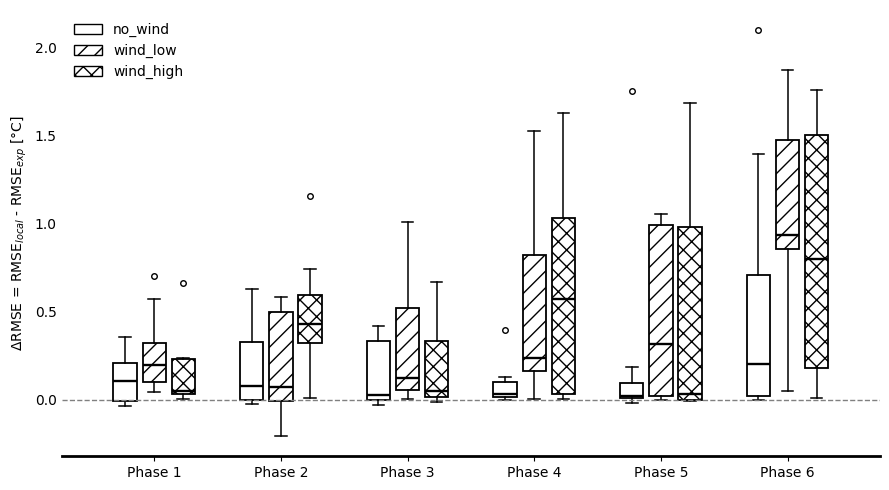

In [10]:
from matplotlib.patches import Patch


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(axis="y", length=0)


HATCHES = {
    "no_wind": "",
    "wind_low": "//",
    "wind_high": "xx",
}

fig, ax = plt.subplots(figsize=(9, 5))

phase_positions = np.arange(len(PHASE_ORDER))
condition_width = 0.23

for condition_index, condition in enumerate(CONDITION_ORDER):
    values_by_phase = [
        paired_difference.loc[
            (
                paired_difference[PHASE_COL] == phase
            )
            & (
                paired_difference[CONDITION_COL] == condition
            ),
            "delta_rmse",
        ]
        .dropna()
        .to_numpy()
        for phase in PHASE_ORDER
    ]

    positions = (
        phase_positions
        + (condition_index - 1) * condition_width
    )

    boxplot = ax.boxplot(
        values_by_phase,
        positions=positions,
        widths=condition_width * 0.8,
        patch_artist=True,
        boxprops={
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 1.3,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.7,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1.1,
        },
        capprops={
            "color": "black",
            "linewidth": 1.1,
        },
        flierprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 4,
        },
    )

    for box in boxplot["boxes"]:
        box.set_hatch(HATCHES[condition])

ax.axhline(
    0,
    color="0.5",
    linewidth=1,
    linestyle="--",
)

ax.set_xticks(phase_positions)
ax.set_xticklabels(
    [PHASE_LABELS[phase] for phase in PHASE_ORDER]
)
ax.set_ylabel(
    r"$\Delta$RMSE = RMSE$_{local}$ - RMSE$_{exp}$ [°C]"
)

legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch=HATCHES[condition],
        label=condition,
    )
    for condition in CONDITION_ORDER
]
ax.legend(
    handles=legend_handles,
    frameon=False,
)

clean_axis(ax)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "delta_rmse_by_phase_condition.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 5. Exponential rate-constant analysis

Inference on \(k\) is restricted to exponential-model fits for which \(k\) is identifiable.
Prediction-valid fits with poorly identified \(k\) remain in the model-performance comparison,
but they are not used to interpret the physiological rate constant.


In [11]:
def analyse_exponential_k(fit_results):
    data = fit_results[
        (fit_results["model"] == "exponential")
        & fit_results["k_identifiable"]
        & np.isfinite(fit_results["k_1_per_s"])
        & (fit_results["k_1_per_s"] > 0)
    ].copy()

    if data.empty:
        raise ValueError(
            "No identifiable exponential k values are available."
        )

    data["log_k"] = np.log(data["k_1_per_s"])
    data[PHASE_COL] = pd.Categorical(
        data[PHASE_COL],
        categories=PHASE_ORDER,
        ordered=True,
    )
    data[CONDITION_COL] = pd.Categorical(
        data[CONDITION_COL],
        categories=CONDITION_ORDER,
        ordered=True,
    )

    full_formula = (
        f"log_k ~ C({CONDITION_COL}) * C({PHASE_COL})"
    )
    additive_formula = (
        f"log_k ~ C({CONDITION_COL}) + C({PHASE_COL})"
    )

    selected_model, interaction_test, selected_formula = (
        fit_nested_mixed_models(
            full_formula=full_formula,
            reduced_formula=additive_formula,
            data=data,
        )
    )

    confidence_intervals = selected_model.conf_int()
    coefficients = pd.DataFrame(
        {
            "term": selected_model.params.index,
            "estimate_log_scale": selected_model.params.values,
            "multiplicative_effect": np.exp(
                selected_model.params.values
            ),
            "se": selected_model.bse.values,
            "ci_low_log": confidence_intervals[0].values,
            "ci_high_log": confidence_intervals[1].values,
            "ci_low_ratio": np.exp(
                confidence_intervals[0].values
            ),
            "ci_high_ratio": np.exp(
                confidence_intervals[1].values
            ),
            "p_value": selected_model.pvalues.values,
        }
    )

    descriptive = (
        data
        .groupby(
            [PHASE_COL, CONDITION_COL],
            observed=True,
        )
        .agg(
            n=("k_1_per_s", "count"),
            median_k_1_per_s=("k_1_per_s", "median"),
            q25_k_1_per_s=(
                "k_1_per_s",
                lambda x: x.quantile(0.25),
            ),
            q75_k_1_per_s=(
                "k_1_per_s",
                lambda x: x.quantile(0.75),
            ),
            median_tau_s=("tau_s", "median"),
        )
        .reset_index()
    )

    coefficients.to_csv(
        OUTPUT_DIR / "exponential_k_mixedlm_coefficients.csv",
        index=False,
    )
    descriptive.to_csv(
        OUTPUT_DIR / "exponential_k_descriptive_summary.csv",
        index=False,
    )
    pd.DataFrame([interaction_test]).to_csv(
        OUTPUT_DIR / "exponential_k_interaction_test.csv",
        index=False,
    )

    print("\nSelected exponential-k model:")
    print(selected_formula)
    print(selected_model.summary())
    print("\nCondition x phase interaction test:", interaction_test)

    display(coefficients)
    display(descriptive)

    return data, selected_model, interaction_test, descriptive


(
    exponential_k_data,
    exponential_k_model,
    exponential_k_interaction_test,
    exponential_k_summary,
) = analyse_exponential_k(fit_results)


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.


Selected exponential-k model:
log_k ~ C(condition) * C(phase)
                           Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             log_k   
No. Observations:              47                  Method:                         REML    
No. Groups:                    10                  Scale:                          0.8421  
Min. group size:               1                   Log-Likelihood:                 -48.0619
Max. group size:               9                   Converged:                      Yes     
Mean group size:               4.7                                                         
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                   

,term,estimate_log_scale,multiplicative_effect,se,ci_low_log,ci_high_log,ci_low_ratio,ci_high_ratio,p_value
0,Intercept,-4.018523,0.017980,0.496731,-4.992097,-3.044949,0.006791,0.047599,5.969209e-16
1,C(condition)[T.wind_low],-0.838676,0.432282,0.676996,-2.165564,0.488212,0.114685,1.629400,2.154123e-01
2,C(condition)[T.wind_high],-0.675981,0.508657,0.639684,-1.929739,0.577778,0.145186,1.782074,2.906298e-01
3,C(phase)[T.walk_low_1],0.397761,1.488488,1.090087,-1.738770,2.534292,0.175736,12.607497,7.151943e-01
4,C(phase)[T.walk_mod_1],1.131527,3.100388,0.752733,-0.343803,2.606857,0.709069,13.556382,1.327810e-01
5,C(phase)[T.walk_low_2],-0.609599,0.543569,0.896375,-2.366462,1.147264,0.093812,3.149564,4.964594e-01
6,C(phase)[T.walk_mod_2],-3.315814,0.036304,1.106087,-5.483705,-1.147924,0.004154,0.317295,2.719461e-03
7,C(phase)[T.standing_2],0.721947,2.058437,0.821091,-0.887363,2.331256,0.411740,10.290860,3.792642e-01
8,C(condition)[T.wind_low]:C(phase)[T.walk_low_1],-0.380257,0.683686,1.306410,-2.940773,2.180258,0.052825,8.848593,7.709974e-01
9,C(condition)[T.wind_high]:C(phase)[T.walk_low_1],-0.086428,0.917202,1.262245,-2.560382,2.387527,0.077275,10.886538,9.454105e-01


,phase,condition,n,median_k_1_per_s,q25_k_1_per_s,q75_k_1_per_s,median_tau_s
0,standing_1,no_wind,4,0.020172,0.013668,0.028092,51.040486
1,standing_1,wind_low,5,0.010765,0.006257,0.011967,92.894224
2,standing_1,wind_high,5,0.008991,0.007330,0.010398,111.219033
3,walk_low_1,no_wind,1,0.029874,0.029874,0.029874,33.473505
4,walk_low_1,wind_low,3,0.021451,0.011272,0.026222,46.618926
5,walk_low_1,wind_high,3,0.012861,0.007992,0.036845,77.753275
6,walk_mod_1,no_wind,3,0.065975,0.041940,0.115890,15.157275
7,walk_mod_1,wind_low,2,0.008800,0.007790,0.009810,119.962898
8,walk_mod_1,wind_high,3,0.012094,0.008595,0.018128,82.688115
9,walk_low_2,no_wind,2,0.018194,0.011488,0.024900,120.366058


## 6. Minimal manuscript figures


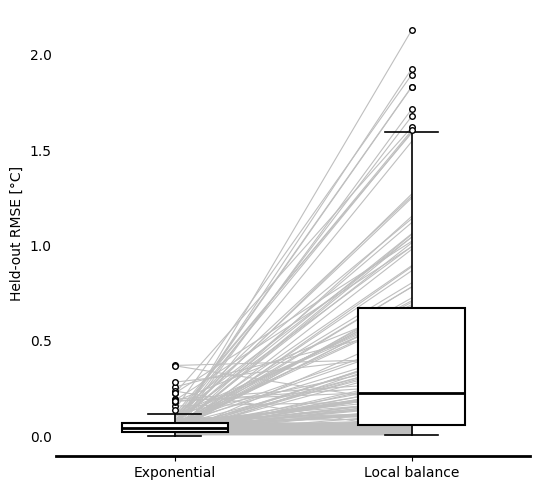

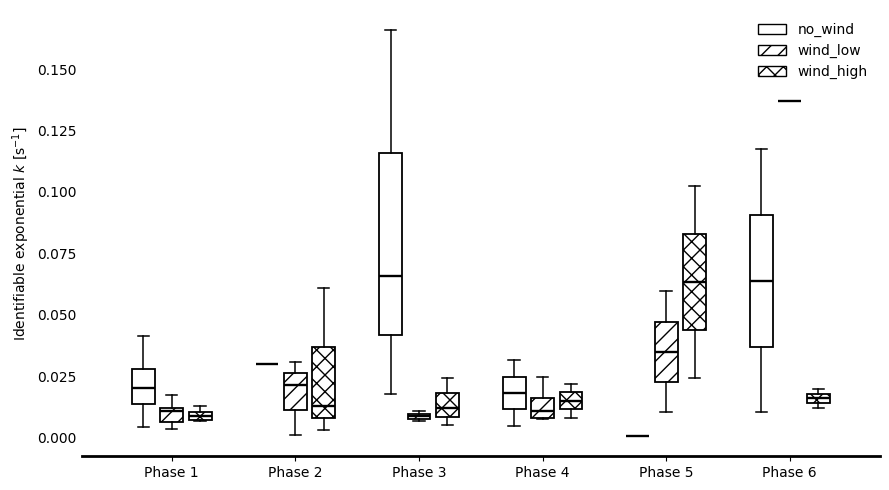

In [12]:
def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(axis="y", length=0)


# Paired held-out RMSE.
wide_plot = (
    paired_results
    .pivot(
        index="trial_id",
        columns="model",
        values="rmse_test",
    )
    .dropna(
        subset=["exponential", "local_balance"]
    )
)

fig, ax = plt.subplots(figsize=(5.5, 5))

for _, row in wide_plot.iterrows():
    ax.plot(
        [0, 1],
        [row["exponential"], row["local_balance"]],
        color="0.75",
        linewidth=0.8,
        zorder=1,
    )

ax.boxplot(
    [
        wide_plot["exponential"],
        wide_plot["local_balance"],
    ],
    positions=[0, 1],
    widths=0.45,
    patch_artist=True,
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.5,
    },
    medianprops={
        "color": "black",
        "linewidth": 2,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.2,
    },
    capprops={
        "color": "black",
        "linewidth": 1.2,
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4,
    },
)

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Exponential", "Local balance"]
)
ax.set_ylabel("Held-out RMSE [°C]")

clean_axis(ax)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "paired_model_rmse_test.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Identifiable exponential k by protocol phase and condition.
fig, ax = plt.subplots(figsize=(9, 5))

phase_positions = np.arange(len(PHASE_ORDER))
condition_width = 0.23

for condition_index, condition in enumerate(CONDITION_ORDER):
    values_by_phase = [
        exponential_k_data.loc[
            (
                exponential_k_data[PHASE_COL] == phase
            )
            & (
                exponential_k_data[CONDITION_COL] == condition
            ),
            "k_1_per_s",
        ]
        .dropna()
        .to_numpy()
        for phase in PHASE_ORDER
    ]

    positions = (
        phase_positions
        + (condition_index - 1) * condition_width
    )

    boxplot = ax.boxplot(
        values_by_phase,
        positions=positions,
        widths=condition_width * 0.8,
        patch_artist=True,
        boxprops={
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 1.3,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.7,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1.1,
        },
        capprops={
            "color": "black",
            "linewidth": 1.1,
        },
        flierprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 4,
        },
    )

    for box in boxplot["boxes"]:
        box.set_hatch(HATCHES[condition])

ax.set_xticks(phase_positions)
ax.set_xticklabels(
    [PHASE_LABELS[phase] for phase in PHASE_ORDER]
)
ax.set_ylabel(
    r"Identifiable exponential $k$ [s$^{-1}$]"
)

legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch=HATCHES[condition],
        label=condition,
    )
    for condition in CONDITION_ORDER
]
ax.legend(
    handles=legend_handles,
    frameon=False,
)

clean_axis(ax)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "identifiable_exponential_k_by_phase_condition.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [15]:
# =============================================================================
# TABLE 3
# Mixed-effects analysis of phase-averaged dorsal-temperature changes
# from the beginning of each experimental test
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import patsy
import statsmodels.formula.api as smf

from scipy.stats import chi2, norm
from statsmodels.stats.multitest import multipletests


# =============================================================================
# 1. CONFIGURATION
# =============================================================================

# Replace this with the dataframe containing the temporal dorsal-temperature data.
#
# Example:
# data = thermal_dynamic_df.copy()
#
data = pd.read_csv(
    "/home/eleonorab/repository/convective_cooling/"
    "data/processed/analysis/analysis_dataset_wide.csv"
)


SUBJECT_COL = "subject_id"
CONDITION_COL = "condition"
PHASE_COL = "phase"
DORSAL_TEMP_COL = "t_dorsal"
TEST_TIME_COL = "elapsed_seconds"


CONDITION_ORDER = [
    "no_wind",
    "wind_low",
    "wind_high",
]

# Correct experimental order reported in the manuscript.
PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]

CONDITION_LABELS = {
    "no_wind": "No ventilation",
    "wind_low": "Low ventilation",
    "wind_high": "High ventilation",
}

PHASE_LABELS = {
    "standing_1": "Standing 1",
    "walk_low_1": "Walk low 1",
    "walk_mod_1": "Walk moderate 1",
    "walk_low_2": "Walk low 2",
    "walk_mod_2": "Walk moderate 2",
    "standing_2": "Standing 2",
}


# Baseline definition:
# mean dorsal temperature during the first BASELINE_WINDOW_S seconds
# of each subject-condition test.
#
# Set this consistently with Figure 1, which reports changes relative
# to the beginning of the test.
BASELINE_WINDOW_S = 60.0

# Minimum amount of data required for a valid baseline.
MIN_BASELINE_POINTS = 3

OUTPUT_DIR = Path(
    "/home/eleonorab/repository/convective_cooling/"
    "reports/04_mechanistic_analysis/table3"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# 2. BASIC VALIDATION
# =============================================================================

required_columns = [
    SUBJECT_COL,
    CONDITION_COL,
    PHASE_COL,
    DORSAL_TEMP_COL,
    TEST_TIME_COL,
]

missing_columns = [
    column
    for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise KeyError(
        "The following required columns are missing:\n"
        f"{missing_columns}\n\n"
        f"Available columns are:\n{data.columns.tolist()}"
    )


data = data[required_columns].copy()

data[DORSAL_TEMP_COL] = pd.to_numeric(
    data[DORSAL_TEMP_COL],
    errors="coerce",
)

data[TEST_TIME_COL] = pd.to_numeric(
    data[TEST_TIME_COL],
    errors="coerce",
)

data = data.dropna(
    subset=[
        SUBJECT_COL,
        CONDITION_COL,
        PHASE_COL,
        DORSAL_TEMP_COL,
        TEST_TIME_COL,
    ]
).copy()


# Keep only recognised conditions and phases.
data = data[
    data[CONDITION_COL].isin(CONDITION_ORDER)
    & data[PHASE_COL].isin(PHASE_ORDER)
].copy()


data[CONDITION_COL] = pd.Categorical(
    data[CONDITION_COL],
    categories=CONDITION_ORDER,
    ordered=True,
)

data[PHASE_COL] = pd.Categorical(
    data[PHASE_COL],
    categories=PHASE_ORDER,
    ordered=True,
)


# Ensure the time starts from zero independently for every
# subject-condition test.
data["test_time_s"] = (
    data[TEST_TIME_COL]
    - data.groupby(
        [SUBJECT_COL, CONDITION_COL],
        observed=True,
    )[TEST_TIME_COL].transform("min")
)


print("Temporal-data shape:", data.shape)

print("\nAvailable observations by condition and phase:")
print(
    data.groupby(
        [PHASE_COL, CONDITION_COL],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
)


# =============================================================================
# 3. COMPUTE TEST-SPECIFIC BASELINE
# =============================================================================

baseline_data = data[
    data["test_time_s"] <= BASELINE_WINDOW_S
].copy()


baseline_summary = (
    baseline_data
    .groupby(
        [SUBJECT_COL, CONDITION_COL],
        observed=True,
    )
    .agg(
        baseline_t_dorsal_C=(DORSAL_TEMP_COL, "mean"),
        baseline_sd_C=(DORSAL_TEMP_COL, "std"),
        baseline_n=(DORSAL_TEMP_COL, "count"),
        baseline_duration_s=("test_time_s", "max"),
    )
    .reset_index()
)


invalid_baselines = baseline_summary[
    baseline_summary["baseline_n"] < MIN_BASELINE_POINTS
].copy()

if not invalid_baselines.empty:
    warnings.warn(
        "Some subject-condition tests had too few baseline points "
        "and will be excluded:\n"
        f"{invalid_baselines}"
    )


baseline_summary = baseline_summary[
    baseline_summary["baseline_n"] >= MIN_BASELINE_POINTS
].copy()


data = data.merge(
    baseline_summary[
        [
            SUBJECT_COL,
            CONDITION_COL,
            "baseline_t_dorsal_C",
        ]
    ],
    on=[
        SUBJECT_COL,
        CONDITION_COL,
    ],
    how="inner",
    validate="many_to_one",
)


# Temperature change from the beginning of the corresponding test.
data["delta_t_dorsal_C"] = (
    data[DORSAL_TEMP_COL]
    - data["baseline_t_dorsal_C"]
)


print("\nBaseline summary:")
print(
    baseline_summary[
        [
            "baseline_t_dorsal_C",
            "baseline_sd_C",
            "baseline_n",
        ]
    ].describe()
)


# =============================================================================
# 4. PHASE-AVERAGED DORSAL-TEMPERATURE CHANGE
# =============================================================================

phase_data = (
    data
    .groupby(
        [
            SUBJECT_COL,
            CONDITION_COL,
            PHASE_COL,
        ],
        observed=True,
    )
    .agg(
        mean_delta_t_dorsal_C=(
            "delta_t_dorsal_C",
            "mean",
        ),
        sd_delta_t_dorsal_C=(
            "delta_t_dorsal_C",
            "std",
        ),
        n_samples=(
            "delta_t_dorsal_C",
            "count",
        ),
        mean_t_dorsal_C=(
            DORSAL_TEMP_COL,
            "mean",
        ),
        baseline_t_dorsal_C=(
            "baseline_t_dorsal_C",
            "first",
        ),
    )
    .reset_index()
)


phase_data[CONDITION_COL] = pd.Categorical(
    phase_data[CONDITION_COL],
    categories=CONDITION_ORDER,
    ordered=True,
)

phase_data[PHASE_COL] = pd.Categorical(
    phase_data[PHASE_COL],
    categories=PHASE_ORDER,
    ordered=True,
)


print("\nPhase-level data shape:", phase_data.shape)

print("\nCounts by condition and phase:")
print(
    phase_data.groupby(
        [PHASE_COL, CONDITION_COL],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
)

print(
    "\nNumber of subjects:",
    phase_data[SUBJECT_COL].nunique(),
)


phase_data.to_csv(
    OUTPUT_DIR / "table3_phase_averaged_dorsal_change.csv",
    index=False,
)


# =============================================================================
# 5. MIXED-EFFECTS MODEL
# =============================================================================

full_formula = (
    "mean_delta_t_dorsal_C ~ "
    f"C({CONDITION_COL}, Treatment(reference='no_wind')) * "
    f"C({PHASE_COL}, Treatment(reference='standing_1'))"
)

additive_formula = (
    "mean_delta_t_dorsal_C ~ "
    f"C({CONDITION_COL}, Treatment(reference='no_wind')) + "
    f"C({PHASE_COL}, Treatment(reference='standing_1'))"
)


def fit_mixedlm(formula, dataframe, reml):
    """
    Fit a random-intercept MixedLM with a small optimizer fallback.
    """
    model = smf.mixedlm(
        formula=formula,
        data=dataframe,
        groups=dataframe[SUBJECT_COL],
        re_formula="1",
    )

    last_error = None

    for method in ["lbfgs", "bfgs", "cg"]:
        try:
            result = model.fit(
                reml=reml,
                method=method,
                maxiter=5000,
                disp=False,
            )

            if result.converged:
                return result

        except Exception as error:
            last_error = error

    if last_error is not None:
        raise RuntimeError(
            "MixedLM failed with all optimizers."
        ) from last_error

    raise RuntimeError(
        "MixedLM did not converge with any optimizer."
    )


# ML fits are required for the likelihood-ratio comparison.
full_model_ml = fit_mixedlm(
    formula=full_formula,
    dataframe=phase_data,
    reml=False,
)

additive_model_ml = fit_mixedlm(
    formula=additive_formula,
    dataframe=phase_data,
    reml=False,
)


lr_statistic = max(
    0.0,
    2.0 * (
        full_model_ml.llf
        - additive_model_ml.llf
    ),
)

lr_df = int(
    full_model_ml.df_modelwc
    - additive_model_ml.df_modelwc
)

lr_p_value = chi2.sf(
    lr_statistic,
    lr_df,
)


interaction_test = pd.DataFrame(
    [
        {
            "test": "condition_by_phase_interaction",
            "LR": lr_statistic,
            "df": lr_df,
            "p_value": lr_p_value,
        }
    ]
)


print("\nGlobal condition x phase interaction:")
print(interaction_test.to_string(index=False))


# Keep the full interaction model for estimating phase-specific contrasts.
# Refit with REML for final coefficient estimation.
full_model = fit_mixedlm(
    formula=full_formula,
    dataframe=phase_data,
    reml=True,
)

print("\nFull MixedLM:")
print(full_model.summary())


interaction_test.to_csv(
    OUTPUT_DIR / "table3_global_interaction_test.csv",
    index=False,
)


# =============================================================================
# 6. PHASE-SPECIFIC MODEL-BASED CONTRASTS
# =============================================================================
#
# For each phase:
#     wind_low  - no_wind
#     wind_high - no_wind
#
# These are simple effects within the phase.
# They are not raw interaction coefficients.
# =============================================================================

design_info = full_model.model.data.design_info

fixed_effect_names = list(
    full_model.fe_params.index
)

fixed_effect_covariance = full_model.cov_params().loc[
    fixed_effect_names,
    fixed_effect_names,
]


def fixed_effect_design_row(condition, phase):
    """
    Construct a fixed-effect design row using exactly the same coding
    adopted by the fitted MixedLM.
    """
    prediction_frame = pd.DataFrame(
        {
            CONDITION_COL: pd.Categorical(
                [condition],
                categories=CONDITION_ORDER,
                ordered=True,
            ),
            PHASE_COL: pd.Categorical(
                [phase],
                categories=PHASE_ORDER,
                ordered=True,
            ),
        }
    )

    design_matrix = patsy.build_design_matrices(
        [design_info],
        prediction_frame,
        return_type="dataframe",
    )[0]

    return design_matrix.loc[
        :,
        fixed_effect_names,
    ].to_numpy(dtype=float).ravel()


contrast_rows = []

for phase in PHASE_ORDER:

    reference_row = fixed_effect_design_row(
        condition="no_wind",
        phase=phase,
    )

    for condition in [
        "wind_low",
        "wind_high",
    ]:

        comparison_row = fixed_effect_design_row(
            condition=condition,
            phase=phase,
        )

        contrast_vector = (
            comparison_row
            - reference_row
        )

        estimate = float(
            contrast_vector
            @ full_model.fe_params.to_numpy()
        )

        variance = float(
            contrast_vector
            @ fixed_effect_covariance.to_numpy()
            @ contrast_vector.T
        )

        standard_error = (
            np.sqrt(variance)
            if variance >= 0
            else np.nan
        )

        if np.isfinite(standard_error) and standard_error > 0:

            z_value = estimate / standard_error

            p_value = 2.0 * norm.sf(
                abs(z_value)
            )

            ci_low = (
                estimate
                - norm.ppf(0.975) * standard_error
            )

            ci_high = (
                estimate
                + norm.ppf(0.975) * standard_error
            )

        else:
            z_value = np.nan
            p_value = np.nan
            ci_low = np.nan
            ci_high = np.nan

        contrast_rows.append(
            {
                "phase": phase,
                "phase_label": PHASE_LABELS[phase],
                "condition": condition,
                "condition_label": CONDITION_LABELS[condition],
                "reference_condition": "no_wind",
                "contrast": (
                    f"{CONDITION_LABELS[condition]} "
                    "- No ventilation"
                ),
                "estimate_C": estimate,
                "standard_error_C": standard_error,
                "z_value": z_value,
                "p_value_raw": p_value,
                "ci_low_C": ci_low,
                "ci_high_C": ci_high,
            }
        )


phase_contrasts = pd.DataFrame(
    contrast_rows
)


# Holm correction across the 12 planned phase-specific contrasts.
valid_p = phase_contrasts[
    "p_value_raw"
].notna()

phase_contrasts.loc[
    valid_p,
    "p_value_holm",
] = multipletests(
    phase_contrasts.loc[
        valid_p,
        "p_value_raw",
    ],
    method="holm",
)[1]


phase_contrasts["significant_raw"] = (
    phase_contrasts["p_value_raw"] < 0.05
)

phase_contrasts["significant_holm"] = (
    phase_contrasts["p_value_holm"] < 0.05
)


# Restore the intended protocol order.
phase_contrasts["phase"] = pd.Categorical(
    phase_contrasts["phase"],
    categories=PHASE_ORDER,
    ordered=True,
)

phase_contrasts["condition"] = pd.Categorical(
    phase_contrasts["condition"],
    categories=[
        "wind_low",
        "wind_high",
    ],
    ordered=True,
)

phase_contrasts = phase_contrasts.sort_values(
    [
        "phase",
        "condition",
    ]
).reset_index(drop=True)


print("\nPhase-specific contrasts:")
print(
    phase_contrasts[
        [
            "phase_label",
            "contrast",
            "estimate_C",
            "ci_low_C",
            "ci_high_C",
            "p_value_raw",
            "p_value_holm",
        ]
    ].to_string(index=False)
)


phase_contrasts.to_csv(
    OUTPUT_DIR / "table3_phase_specific_contrasts_all.csv",
    index=False,
)


# =============================================================================
# 7. FINAL TABLE 3
# =============================================================================
#
# I advise reporting all planned contrasts, not only significant ones.
# The global interaction test should be reported in the text or caption.
# =============================================================================

table3 = phase_contrasts[
    [
        "phase_label",
        "contrast",
        "estimate_C",
        "ci_low_C",
        "ci_high_C",
        "p_value_holm",
    ]
].copy()


table3["Estimated difference [C]"] = (
    table3["estimate_C"].map(
        lambda value: f"{value:.2f}"
    )
)

table3["95% CI [C]"] = table3.apply(
    lambda row: (
        f"[{row['ci_low_C']:.2f}, "
        f"{row['ci_high_C']:.2f}]"
    ),
    axis=1,
)

table3["Adjusted p-value"] = (
    table3["p_value_holm"].map(
        lambda value: (
            "<0.001"
            if value < 0.001
            else f"{value:.3f}"
        )
    )
)


table3_final = table3[
    [
        "phase_label",
        "contrast",
        "Estimated difference [C]",
        "95% CI [C]",
        "Adjusted p-value",
    ]
].rename(
    columns={
        "phase_label": "Phase",
        "contrast": "Comparison",
    }
)


print("\nFinal Table 3:")
print(
    table3_final.to_string(index=False)
)


table3_final.to_csv(
    OUTPUT_DIR / "table3_final.csv",
    index=False,
)




Temporal-data shape: (10080, 6)

Available observations by condition and phase:
condition   no_wind  wind_low  wind_high
phase                                   
standing_1      600       600        480
walk_low_1      600       600        480
walk_mod_1      600       600        480
walk_low_2      600       600        480
walk_mod_2      600       600        480
standing_2      600       600        480

Baseline summary:
       baseline_t_dorsal_C  baseline_sd_C  baseline_n
count            28.000000      28.000000        28.0
mean             35.647429       0.065021         7.0
std               0.500694       0.027231         0.0
min              34.469429       0.023434         7.0
25%              35.318071       0.046868         7.0
50%              35.690214       0.063706         7.0
75%              35.975179       0.074971         7.0
max              36.616714       0.121719         7.0

Phase-level data shape: (168, 8)

Counts by condition and phase:
condition   no_wind  

/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Global condition x phase interaction:
                          test        LR  df  p_value
condition_by_phase_interaction 17.528402  10 0.063459


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Full MixedLM:
                                                            Mixed Linear Model Regression Results
Model:                                           MixedLM                               Dependent Variable:                               mean_delta_t_dorsal_C
No. Observations:                                168                                   Method:                                           REML                 
No. Groups:                                      10                                    Scale:                                            0.4075               
Min. group size:                                 12                                    Log-Likelihood:                                   -172.0782            
Max. group size:                                 18                                    Converged:                                        Yes                  
Mean group size:                                 16.8                                       

## Outputs and interpretation rules

- `dynamic_model_fit_results_all.csv` retains every attempted fit and the reason for any exclusion.
- Predictive comparison uses every trial with finite predictions from both models, regardless of parameter identifiability.
- Both models are fitted on the same training interval and evaluated on the same held-out dorsal-temperature samples.
- `delta_rmse > 0` and `log_ratio_rmse > 0` indicate better predictive performance of the exponential model.
- A low test \(R^2\) is a model result, not an exclusion criterion.
- Inference on \(k\) uses only identifiable exponential-model estimates.
- The local-balance \(k\) is retained in the complete output table for transparency but is not interpreted as a physiological rate constant.
- Statistical significance must be reported together with effect estimates, confidence intervals, fit counts, and the subject-level sensitivity analysis.
